90%

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Define the Fire module (core component of SqueezeNet)
def fire_module(x, squeeze_filters, expand_filters):
    # Squeeze layer
    squeeze = layers.Conv2D(squeeze_filters, (1, 1), padding='same', activation='relu')(x)
    
    # Expand layer
    expand1x1 = layers.Conv2D(expand_filters, (1, 1), padding='same', activation='relu')(squeeze)
    expand3x3 = layers.Conv2D(expand_filters, (3, 3), padding='same', activation='relu')(squeeze)
    
    # Concatenate the expand outputs
    x = layers.Concatenate()([expand1x1, expand3x3])
    
    return x

# Define Squeeze-and-Excitation block
def squeeze_excite_block(input_tensor, ratio=16):
    filters = input_tensor.shape[-1]
    se = layers.GlobalAveragePooling2D()(input_tensor)
    se = layers.Reshape((1, 1, filters))(se)
    se = layers.Dense(filters // ratio, activation='relu', use_bias=False)(se)
    se = layers.Dense(filters, activation='sigmoid', use_bias=False)(se)
    x = layers.Multiply()([input_tensor, se])
    return x

# Define SqueezeNet architecture with SE blocks
def create_squeezenet(input_shape=(224, 224, 3), classes=5):
    inputs = layers.Input(shape=input_shape)

    # Initial Conv Layer
    x = layers.Conv2D(64, (3, 3), strides=(2, 2), padding='same', activation='relu')(inputs)
    x = layers.MaxPooling2D(pool_size=(3, 3), strides=(2, 2))(x)
    
    # Fire modules with reduced parameters
    x = fire_module(x, squeeze_filters=16, expand_filters=32)
    x = fire_module(x, squeeze_filters=16, expand_filters=32)
    x = layers.MaxPooling2D(pool_size=(3, 3), strides=(2, 2))(x)
    
    x = fire_module(x, squeeze_filters=32, expand_filters=64)
    x = fire_module(x, squeeze_filters=32, expand_filters=64)
    
    # Add Squeeze-and-Excitation block to the final fire module
    x = squeeze_excite_block(x)

    # Global Average Pooling
    x = layers.GlobalAveragePooling2D()(x)
    
    # Dropout for regularization
    x = layers.Dropout(0.5)(x)

    # Output layer with softmax activation for 5 classes
    outputs = layers.Dense(classes, activation='softmax')(x)

    # Create the model
    model = models.Model(inputs=inputs, outputs=outputs)
    
    return model

# Create the SqueezeNet model
model = create_squeezenet()

# Compile the model using categorical crossentropy for multiclass classification
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Model summary
model.summary()


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d (Conv2D)                (None, 112, 112, 64  1792        ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 max_pooling2d (MaxPooling2D)   (None, 55, 55, 64)   0           ['conv2d[0][0]']                 
                                                                                              

In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

# Define image data generators for training and validation datasets
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

# Load train and validation datasets from directories
train_generator = train_datagen.flow_from_directory(
    r'C:\MyFolders\Projects\major_project\classification\dataset\aptos_resized_kaggle\aug_split_data\train',  
    target_size=(224, 224),
    batch_size=8, 
    class_mode='categorical' 
)

validation_generator = val_datagen.flow_from_directory(
    r"C:\MyFolders\Projects\major_project\classification\dataset\aptos_resized_kaggle\aug_split_data\val",
    target_size=(224, 224),
    batch_size=8,
    class_mode='categorical'
)

# Train the model for 50 epochs
history = model.fit(
    train_generator,
    epochs=50, 
    validation_data=validation_generator
)

Found 8883 images belonging to 5 classes.
Found 1113 images belonging to 5 classes.
Epoch 1/50
1111/1111 [==============================] - 21s 15ms/step - loss: 1.0281 - accuracy: 0.5928 - val_loss: 0.5944 - val_accuracy: 0.8347
Epoch 2/50
1111/1111 [==============================] - 16s 14ms/step - loss: 0.5067 - accuracy: 0.8558 - val_loss: 0.4393 - val_accuracy: 0.8742
Epoch 3/50
1111/1111 [==============================] - 16s 14ms/step - loss: 0.4345 - accuracy: 0.8689 - val_loss: 0.3876 - val_accuracy: 0.8760
Epoch 4/50
1111/1111 [==============================] - 22s 19ms/step - loss: 0.4084 - accuracy: 0.8774 - val_loss: 0.3793 - val_accuracy: 0.8832
Epoch 5/50
1111/1111 [==============================] - 30s 27ms/step - loss: 0.3815 - accuracy: 0.8831 - val_loss: 0.3535 - val_accuracy: 0.8868
Epoch 6/50
1111/1111 [==============================] - 16s 14ms/step - loss: 0.3667 - accuracy: 0.8869 - val_loss: 0.3334 - val_accuracy: 0.8967
Epoch 7/50
1111/1111 [==================

In [9]:
test_datagen = ImageDataGenerator(rescale=1./255)

# Load train and validation datasets from directories
test_generator = train_datagen.flow_from_directory(
    r'C:\MyFolders\Projects\major_project\classification\dataset\aptos_resized_kaggle\aug_split_data\test',  
    target_size=(224, 224),
    batch_size=8, 
    class_mode='categorical' 
)

# Evaluate on test set
test_loss, test_acc = model.evaluate(test_generator)
print(f'Test Accuracy: {test_acc}')

Found 1110 images belonging to 5 classes.
139/139 [==============================] - 2s 11ms/step - loss: 0.3620 - accuracy: 0.8937
Test Accuracy: 0.8936936855316162


In [8]:
model.save(r"C:\MyFolders\Projects\major_project\classification\codes\aptos\squeezenet2_try.h5")

import pickle
with open('history_squeeze2.pkl', 'wb') as f:
    pickle.dump(history.history, f)

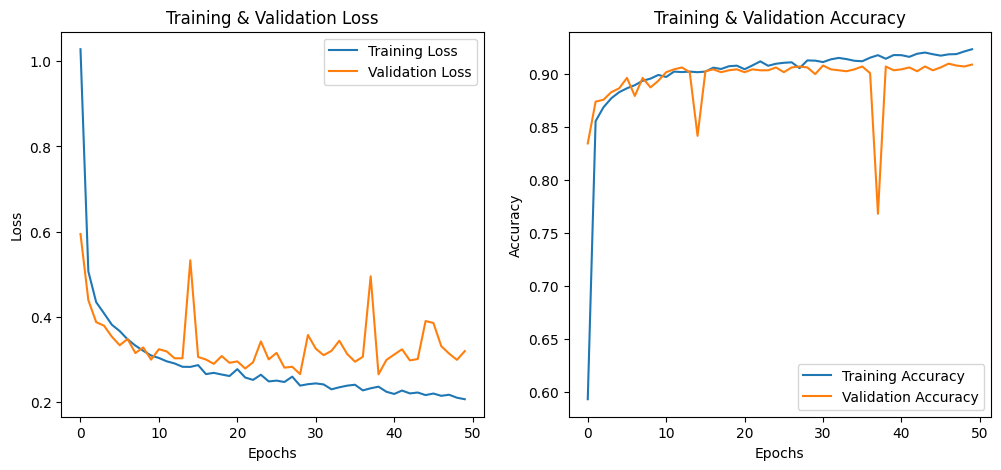

In [7]:
import matplotlib.pyplot as plt

def plot_loss_accuracy(history):
    # Plot Training & Validation Loss
    plt.figure(figsize=(12, 5))
    
    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Training & Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Training & Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.show()

# After training the model, pass the history object to the function
plot_loss_accuracy(history)

In [11]:
import matplotlib.pyplot as plt
import pickle
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Load the saved model
model = load_model(r'C:\MyFolders\Projects\major_project\classification\codes\aptos\squeezenet2_try.h5')

# Define image data generator for validation dataset
val_datagen = ImageDataGenerator(rescale=1./255)

# Load validation dataset from directory
validation_generator = val_datagen.flow_from_directory(
    r"C:\MyFolders\Projects\major_project\classification\dataset\aptos_resized_kaggle\aug_split_data\val",
    target_size=(224, 224),
    batch_size=8,
    class_mode='categorical'
)

# Evaluate the model
loss, accuracy = model.evaluate(validation_generator)
print(f"Validation Loss: {loss}, Validation Accuracy: {accuracy}")


Found 1113 images belonging to 5 classes.
140/140 [==============================] - 2s 12ms/step - loss: 0.3196 - accuracy: 0.9093
Validation Loss: 0.31959617137908936, Validation Accuracy: 0.909254252910614


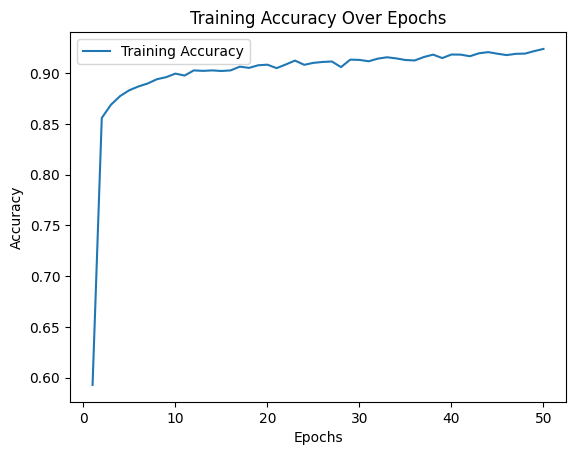

Final Training Accuracy: 0.9238


In [16]:
import pickle
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

# Load the saved model
model_path = r'C:\MyFolders\Projects\major_project\classification\codes\aptos\squeezenet2_try.h5'  # Adjust the path to your saved model
model = load_model(model_path)

# Load training history
history_path = r'C:\MyFolders\Projects\major_project\classification\codes\aptos\history_squeeze2.pkl'  # Adjust the path to your training history
with open(history_path, 'rb') as f:  # Use 'rb' for reading binary files
    history = pickle.load(f)

# Extract training accuracy
epochs = range(1, len(history['accuracy']) + 1)
train_accuracy = history['accuracy']

# Plot training accuracy
plt.figure()
plt.plot(epochs, train_accuracy, label='Training Accuracy')
plt.title('Training Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Get the final training accuracy from the history
final_train_accuracy = train_accuracy[-1]
print(f'Final Training Accuracy: {final_train_accuracy:.4f}')


In [12]:
import json
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

# Load the saved model
model_path = r'C:\MyFolders\Projects\major_project\classification\codes\aptos\squeezenet2_try.h5'  # Adjust the path to your saved model
model = load_model(model_path)

# Load training history
history_path = r'C:\MyFolders\Projects\major_project\classification\codes\aptos\history_squeeze2.pkl'  # Adjust the path to your training history
with open(history_path, 'r') as f:
    history = json.load(f)

# Extract training accuracy
epochs = range(1, len(history['accuracy']) + 1)
train_accuracy = history['accuracy']

# # Plot training accuracy over epochs
# plt.figure(figsize=(10, 6))
# plt.plot(epochs, train_accuracy, label='Training Accuracy', color='blue', marker='o')
# plt.title('Training Accuracy Over 50 Epochs', fontsize=16)
# plt.xlabel('Epochs', fontsize=14)
# plt.ylabel('Accuracy', fontsize=14)
# plt.xticks(epochs)
# plt.ylim(0, 1)  # Accuracy ranges from 0 to 1
# plt.grid(True, linestyle='--', alpha=0.6)
# plt.legend()
# plt.show()


UnicodeDecodeError: 'charmap' codec can't decode byte 0x90 in position 55: character maps to <undefined>

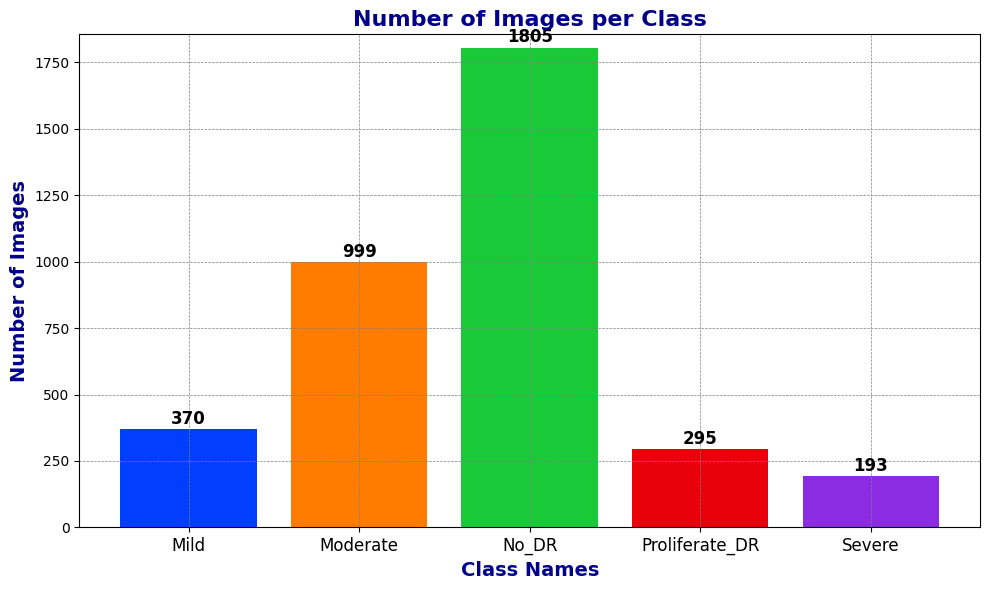

In [10]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Path to dataset directory
dataset_dir = r'C:\MyFolders\Projects\major_project\classification\dataset\aptos_resized_kaggle\colored_images'

# Get the number of images in each class
class_names = []
image_counts = []

for class_folder in os.listdir(dataset_dir):
    class_path = os.path.join(dataset_dir, class_folder)
    if os.path.isdir(class_path):
        num_images = len(os.listdir(class_path))
        class_names.append(class_folder)
        image_counts.append(num_images)

# Create a bar plot
fig, ax = plt.subplots(figsize=(10, 6))

# Use a bright color palette
palette = sns.color_palette("bright", len(class_names))
bars = ax.bar(class_names, image_counts, color=palette)

# Add number of images on top of each bar in bold
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 5, f'{height}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Add grids (both horizontal and vertical)
ax.grid(True, which='both', axis='both', linestyle='--', linewidth=0.5, color='gray')

# Set the x-axis labels to be horizontal
plt.xticks(rotation=0, fontsize=12)

# Set plot title and labels
ax.set_title('Number of Images per Class', fontsize=16, color='darkblue', fontweight='bold')
ax.set_xlabel('Class Names', fontsize=14, color='darkblue', fontweight='bold')
ax.set_ylabel('Number of Images', fontsize=14, color='darkblue', fontweight='bold')

# Adjust the y-axis to ensure visibility of text above bars
ax.set_ylim(0, max(image_counts) + 50)

# Show the plot
plt.tight_layout()
plt.show()


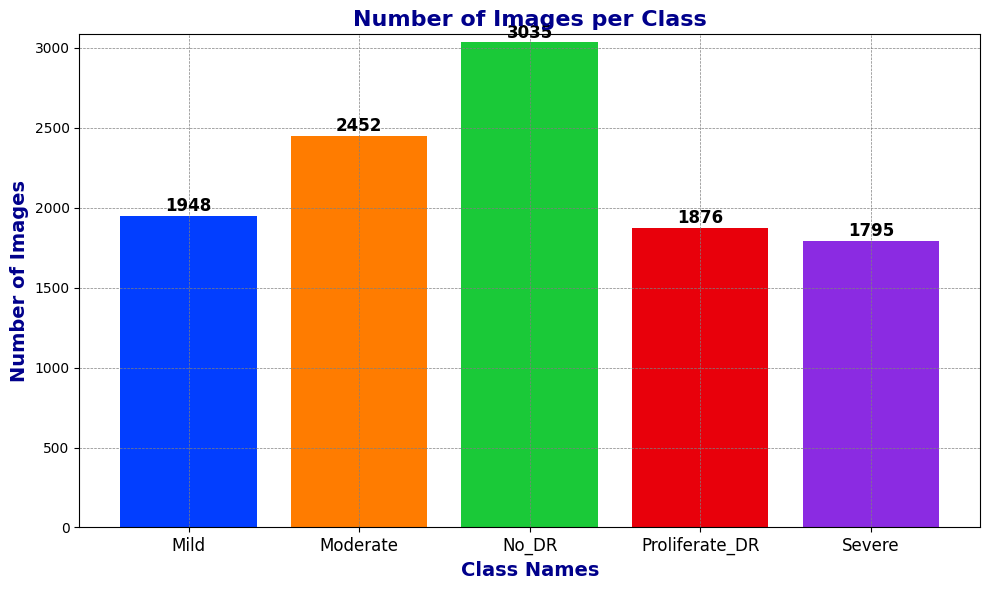

In [8]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Path to dataset directory
dataset_dir = r'C:\MyFolders\Projects\major_project\classification\dataset\aptos_resized_kaggle\augmented_data'

# Get the number of images in each class
class_names = []
image_counts = []

for class_folder in os.listdir(dataset_dir):
    class_path = os.path.join(dataset_dir, class_folder)
    if os.path.isdir(class_path):
        num_images = len(os.listdir(class_path))
        class_names.append(class_folder)
        image_counts.append(num_images)

# Create a bar plot
fig, ax = plt.subplots(figsize=(10, 6))

# Use a bright color palette
palette = sns.color_palette("bright", len(class_names))
bars = ax.bar(class_names, image_counts, color=palette)

# Add number of images on top of each bar in bold
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 5, f'{height}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Add grids (both horizontal and vertical)
ax.grid(True, which='both', axis='both', linestyle='--', linewidth=0.5, color='gray')

# Set the x-axis labels to be horizontal
plt.xticks(rotation=0, fontsize=12)

# Set plot title and labels
ax.set_title('Number of Images per Class', fontsize=16, color='darkblue', fontweight='bold')
ax.set_xlabel('Class Names', fontsize=14, color='darkblue', fontweight='bold')
ax.set_ylabel('Number of Images', fontsize=14, color='darkblue', fontweight='bold')

# Adjust the y-axis to ensure visibility of text above bars
ax.set_ylim(0, max(image_counts) + 50)

# Show the plot
plt.tight_layout()
plt.show()


In [ ]:
import os
import pandas as pd
import numpy as np
from keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import load_model

# Function to predict labels using a given model
def generate_pred_labels(model_path, test_data_dir, output_csv_path):
    # Load the trained model
    model = load_model(model_path)
    
    # Create a list to hold the image file names and their corresponding predicted labels
    pred_data = []

    # Iterate through each class folder in the test dataset
    for class_folder in os.listdir(test_data_dir):
        class_path = os.path.join(test_data_dir, class_folder)
        
        if os.path.isdir(class_path):
            # List all images in the class folder
            for image_name in os.listdir(class_path):
                # Load and preprocess the image
                image_path = os.path.join(class_path, image_name)
                image = load_img(image_path, target_size=(224, 224))  # Adjust the target size based on your model's input
                image_array = img_to_array(image) / 255.0  # Normalize the image
                image_array = np.expand_dims(image_array, axis=0)  # Add batch dimension

                # Make prediction
                pred = model.predict(image_array)
                predicted_label = np.argmax(pred, axis=1)[0]  # Get the index of the highest probability
                
                # Append the image file name and its predicted label to the pred_data list
                pred_data.append({'id_code': image_name, 'predicted_diagnosis': predicted_label})

    # Create a DataFrame and save to CSV
    pred_labels_df = pd.DataFrame(pred_data)
    pred_labels_df.to_csv(output_csv_path, index=False)

    print("CSV file with predicted labels created successfully.")

# Example usage
model_path = r'C:\MyFolders\Projects\major_project\classification\codes\aptos\squeezenet_aug.h5'  # Path to your trained model
test_data_dir = r'C:\MyFolders\Projects\major_project\classification\dataset\aptos_resized_kaggle\aug_split_data\test'  # Path to your test images
output_csv_path = r'C:\MyFolders\Projects\major_project\classification\codes\aptos\pred_label_squeezenet.csv'  # Path for the output CSV file

# Call the function to generate predicted labels
generate_pred_labels(model_path, test_data_dir, output_csv_path)
